# Task 6: Per-index EDA — processed data (`data/processed/`)
part 3 of 3 ([raw](eda_raw.ipynb) → [interim](eda_interim.ipynb) → processed)

**Goal:** check the Milestone 1 outputs (Tasks 4-5) and take a first look at the project question:
*do the AI job-risk indices agree?* Also check whether the three-way join changed who is in the data.

**Reads:** `merged_ai_risk_v0.csv` (+ `.xlsx` copy) and `coverage_report_v0.csv`, plus the interim tables
for reconciliation. **Writes:** nothing.

| Part | File | What it is |
|---|---|---|
| 1 | `merged_ai_risk_v0.csv` (+ `.xlsx` copy) | Occupations scored by all three indices, on SOC 2018 |
| 2 | `coverage_report_v0.csv` | Every occupation dropped from the merged table, with the reason |

**Analysis decisions**
- **Headline score per index:** Eloundou `dv_rating_beta` (GPT-4 rater; `human_rating_beta` shown alongside),
  `AIOE`, and Frey-Osborne `probability`. Higher always means more exposed or at higher risk.
- **Compare indices by rank only (Spearman).** The scales differ (share of tasks, z-score, probability)
  and Frey-Osborne is bimodal, so Pearson correlations or raw differences would mislead.
- **Selection bias is measured, not assumed.** For each index, the rows that survive the join are
  compared with the rows that don't.

**Carried over from the interim EDA:** Frey-Osborne misses 168 SOC 2018 codes, mostly in education and
healthcare. Part 1 §6 and Part 2 show what that does to the merged table.

## Setup

Works in **Google Colab** and **locally**:
- **Colab:** mounts Google Drive and reads from the team folder
  `MyDrive/BTT Fall AI Studio (swytch 1b)/data/` (the same folder `Milestone_1.ipynb` uses). If the folder was
  shared with you, add a shortcut to it in *My Drive* first. Any file missing from Drive is downloaded
  from the GitHub repo instead, so the notebook still runs without Drive access.
- **Locally:** reads `data/` from the repo (run from anywhere inside the repo with the project `.venv`).

In [1]:
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/BTT Fall AI Studio (swytch 1b)")
else:
    # Repo root = nearest folder (this one or above) that contains data/, so any notebooks/ subfolder works
    ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir()), Path.cwd())

DATA = ROOT / "data"
# Fallback source for files not found under DATA (switch the branch to main once this is merged)
GITHUB_DATA = "https://raw.githubusercontent.com/Break-Through-Tech/Swytch-1B-do-ai-job-risk-indices-agree/kamsi/data"
print("data folder:", DATA, "(found)" if DATA.exists() else "(not found, using GitHub)")


def data_file(rel):
    """Path to data/<rel>: from Drive / the repo if present, else downloaded once from GitHub."""
    path = DATA / rel
    if path.exists():
        return path
    cached = Path(tempfile.gettempdir()) / "swytch_data" / rel
    if not cached.exists():
        cached.parent.mkdir(parents=True, exist_ok=True)
        print(f"downloading {rel} from GitHub")
        urllib.request.urlretrieve(f"{GITHUB_DATA}/{rel}", cached)
    return cached


OUT = (ROOT if ROOT.exists() else Path.cwd()) / "notebooks" / "figures"
OUT.mkdir(parents=True, exist_ok=True)

MAJOR_GROUPS = {
    "11": "Management", "13": "Business & Financial", "15": "Computer & Mathematical",
    "17": "Architecture & Engineering", "19": "Life, Physical & Social Sci.",
    "21": "Community & Social Service", "23": "Legal", "25": "Education & Library",
    "27": "Arts, Design & Media", "29": "Healthcare Practitioners", "31": "Healthcare Support",
    "33": "Protective Service", "35": "Food Preparation & Serving", "37": "Building & Grounds",
    "39": "Personal Care & Service", "41": "Sales", "43": "Office & Admin Support",
    "45": "Farming, Fishing & Forestry", "47": "Construction & Extraction",
    "49": "Installation & Repair", "51": "Production", "53": "Transportation & Material Moving",
    "55": "Military",
}


def boxplot_by_group(df, code_col, value_col, title):
    """Horizontal boxplot of value_col per SOC major group, sorted by median."""
    groups = df.assign(mg=df[code_col].str[:2]).groupby("mg")[value_col]
    order = groups.median().sort_values().index
    data = [groups.get_group(g) for g in order]
    fig, ax = plt.subplots(figsize=(8, 7))
    try:
        ax.boxplot(data, orientation="horizontal")  # matplotlib >= 3.10
    except TypeError:
        ax.boxplot(data, vert=False)
    ax.set_yticks(range(1, len(order) + 1), [f"{g} {MAJOR_GROUPS[g]}" for g in order])
    ax.set_xlabel(value_col)
    ax.set_title(title, loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    plt.show()


def load_crosswalk():
    """BLS SOC 2010 -> 2018 crosswalk with short column names."""
    cw = pd.read_excel(data_file("raw/soc_2010_to_2018_crosswalk.xlsx"), header=8, dtype=str)
    cw.columns = ["soc10", "title10", "soc18", "title18"]
    return cw.apply(lambda s: s.str.strip())

data folder: C:\Users\Kamsi\Downloads\code\Swytch-1B-do-ai-job-risk-indices-agree\data (found)


In [2]:
HEADLINE = ["dv_rating_beta", "human_rating_beta", "AIOE", "probability"]
cw = load_crosswalk()
soc18 = set(cw.soc18)
elo6 = pd.read_csv(data_file("interim/eloundou_soc6.csv")).rename(columns={"soc6": "soc"})
aioe_x = pd.read_csv(data_file("interim/aioe_soc2018.csv")).rename(columns={"soc2018": "soc"})
fo_x = pd.read_csv(data_file("interim/frey_osborne_soc2018.csv")).rename(columns={"soc2018": "soc"})
print(f"interim tables: Eloundou {len(elo6)} | AIOE {len(aioe_x)} | Frey-Osborne {len(fo_x)} | SOC 2018 codes {len(soc18)}")

interim tables: Eloundou 798 | AIOE 800 | Frey-Osborne 699 | SOC 2018 codes 867


## Part 1 — Merged table (`merged_ai_risk_v0.csv`)

### 1. Load + integrity checks

In [3]:
merged = pd.read_csv(data_file("processed/merged_ai_risk_v0.csv"))
print("rows:", len(merged), "| columns:", len(merged.columns))
print("nulls:", merged.isna().sum()[lambda s: s > 0].to_dict(), "| duplicate codes:", merged.soc.duplicated().sum())
assert merged.soc.str.fullmatch(r"\d{2}-\d{4}").all() and set(merged.soc) <= soc18
print("n_sources:", merged.n_sources.value_counts().to_dict())
print(merged.dtypes.value_counts().to_dict())

xlsx = pd.read_excel(data_file("processed/merged_ai_risk_v0.xlsx"))
same = xlsx.shape == merged.shape and (xlsx.columns == merged.columns).all()
print("xlsx copy has same shape/columns:", same,
      "| same headline values:", bool(np.allclose(xlsx[HEADLINE], merged[HEADLINE])) if same else "n/a")

rows: 693 | columns: 26
nulls: {} | duplicate codes: 0
n_sources: {3: 693}
{dtype('float64'): 11, <StringDtype(storage='python', na_value=nan)>: 7, dtype('bool'): 7, dtype('int64'): 1}


xlsx copy has same shape/columns: True | same headline values: True


### 2. Reconcile with the interim tables

In [4]:
def max_diff(interim, cols):
    j = merged[["soc"] + cols].merge(interim[["soc"] + cols], on="soc", suffixes=("", "_i"))
    return len(j), max((j[c] - j[f"{c}_i"]).abs().max() for c in cols)

for name, interim, cols in [("Eloundou", elo6, [c for c in elo6.columns if "rating" in c]),
                            ("AIOE", aioe_x, ["AIOE"]), ("Frey-Osborne", fo_x, ["probability"])]:
    n, d = max_diff(interim, cols)
    print(f"{name:<13} rows matched: {n} of {len(merged)} | max |merged - interim|: {d:.1e}")

Eloundou      rows matched: 693 of 693 | max |merged - interim|: 0.0e+00
AIOE          rows matched: 693 of 693 | max |merged - interim|: 0.0e+00
Frey-Osborne  rows matched: 693 of 693 | max |merged - interim|: 0.0e+00


### 3. Distributions in the merged table

       dv_rating_beta  human_rating_beta     AIOE  probability
count         693.000            693.000  693.000      693.000
mean            0.313              0.274   -0.057        0.534
std             0.225              0.208    0.990        0.370
min             0.000              0.000   -2.670        0.003
25%             0.106              0.081   -0.885        0.100
50%             0.289              0.250   -0.182        0.640
75%             0.488              0.447    0.923        0.890
max             1.000              0.844    1.526        0.990


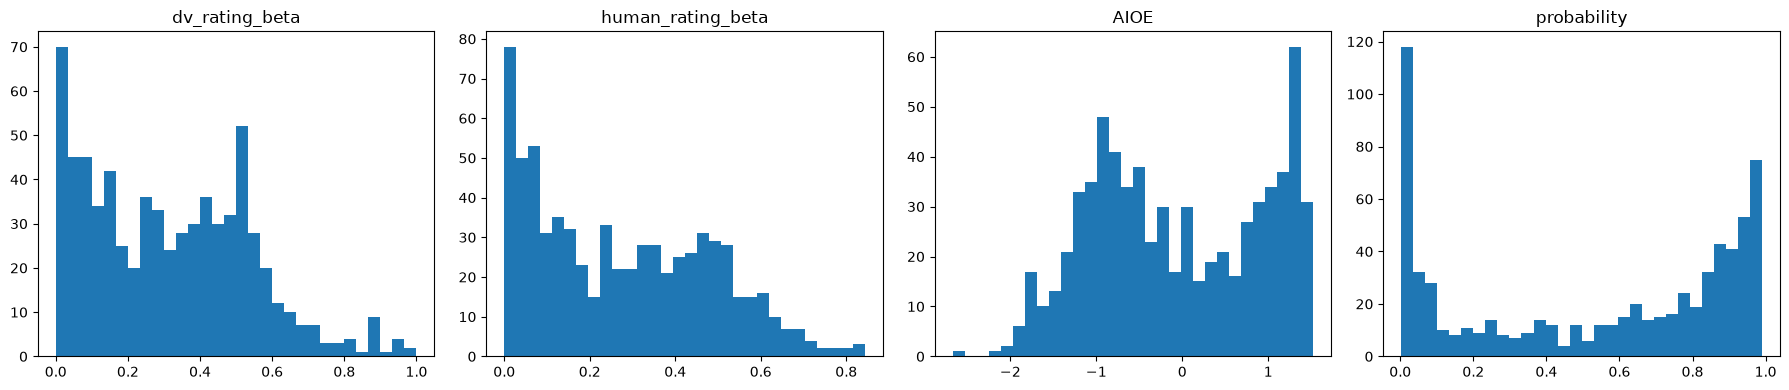

In [5]:
print(merged[HEADLINE].describe().round(3))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, HEADLINE):
    ax.hist(merged[col], bins=30)
    ax.set_title(col)
fig.tight_layout()
plt.show()

### 4. Do the indices agree?
Spearman rank correlations (scale-free, and robust to Frey-Osborne's bimodality).

                   dv_rating_beta  human_rating_beta   AIOE  probability
dv_rating_beta              1.000              0.910  0.859       -0.260
human_rating_beta           0.910              1.000  0.861       -0.335
AIOE                        0.859              0.861  1.000       -0.363
probability                -0.260             -0.335 -0.363        1.000


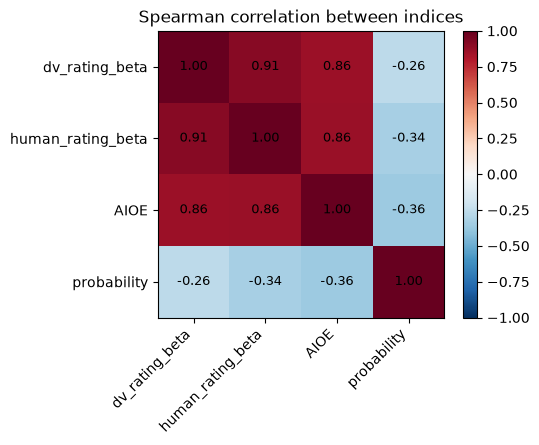

In [6]:
rho = merged[HEADLINE].corr(method="spearman")
print(rho.round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(rho, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(HEADLINE)), HEADLINE, rotation=45, ha="right")
ax.set_yticks(range(len(HEADLINE)), HEADLINE)
for i in range(len(HEADLINE)):
    for j in range(len(HEADLINE)):
        ax.text(j, i, f"{rho.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax)
ax.set_title("Spearman correlation between indices")
fig.tight_layout()
plt.show()

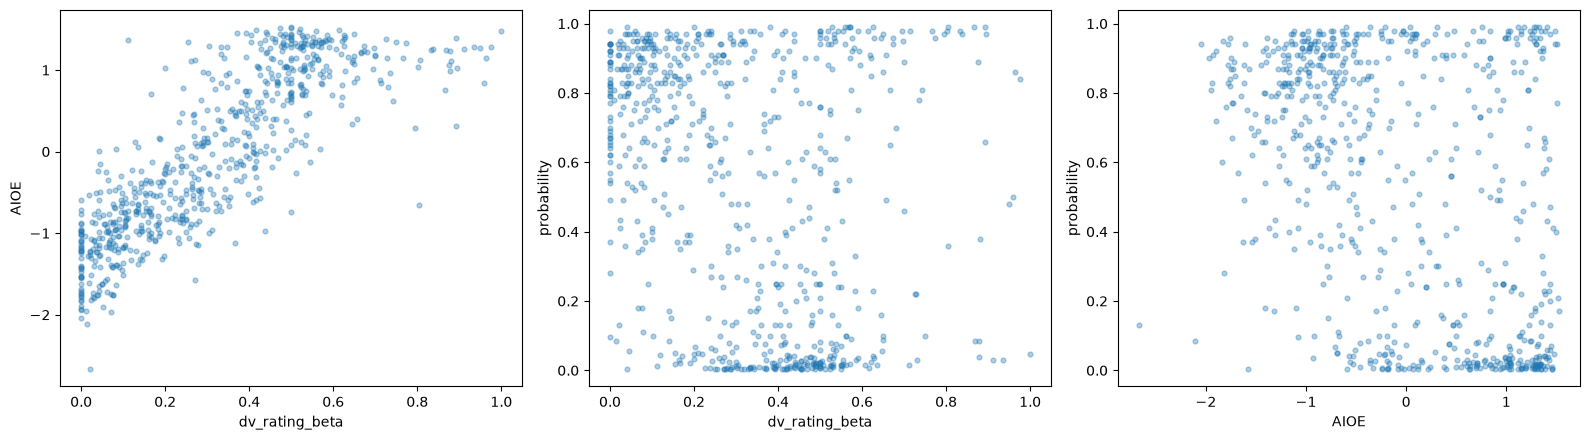

In [7]:
pairs = [("dv_rating_beta", "AIOE"), ("dv_rating_beta", "probability"), ("AIOE", "probability")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(merged[x], merged[y], alpha=0.35, s=12)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
fig.tight_layout()
plt.show()

In [8]:
# Where they disagree most: rank gap between the two AI-exposure indices and Frey-Osborne
pct = merged[HEADLINE].rank(pct=True)
merged["gap_aioe_fo"] = pct["AIOE"] - pct["probability"]
show = ["soc", "title_aioe", "dv_rating_beta", "AIOE", "probability", "gap_aioe_fo"]
print("High AI exposure (AIOE) but low automation risk (Frey-Osborne):")
print(merged.nlargest(8, "gap_aioe_fo")[show].round(2).to_string(index=False))
print("\nLow AI exposure but high automation risk:")
print(merged.nsmallest(8, "gap_aioe_fo")[show].round(2).to_string(index=False))
merged = merged.drop(columns="gap_aioe_fo")

High AI exposure (AIOE) but low automation risk (Frey-Osborne):
    soc                              title_aioe  dv_rating_beta  AIOE  probability  gap_aioe_fo
19-3033   Clinical and Counseling Psychologists            0.37  1.46         0.00         0.95
19-3034                    School Psychologists            0.39  1.46         0.00         0.95
19-3039                Psychologists, All Other            0.45  1.39         0.00         0.93
11-9033 Education Administrators, Postsecondary            0.44  1.46         0.01         0.92
29-1031            Dietitians and Nutritionists            0.55  1.34         0.00         0.91
21-1014                Mental Health Counselors            0.25  1.34         0.00         0.89
19-3032 Industrial-Organizational Psychologists            0.49  1.40         0.01         0.89
25-9031              Instructional Coordinators            0.49  1.30         0.00         0.88

Low AI exposure but high automation risk:
    soc                      

In [9]:
by_mg = merged.assign(mg=merged.soc.str[:2]).groupby("mg")[HEADLINE].median()
by_mg.index = [f"{g} {MAJOR_GROUPS[g]}" for g in by_mg.index]
by_mg.rank(pct=True).round(2).sort_values("dv_rating_beta")

,dv_rating_beta,human_rating_beta,AIOE,probability
47 Construction & Extraction,0.05,0.05,0.05,0.77
37 Building & Grounds,0.09,0.09,0.09,0.68
51 Production,0.14,0.14,0.18,0.95
49 Installation & Repair,0.18,0.23,0.23,0.64
35 Food Preparation & Serving,0.23,0.27,0.32,0.91
"45 Farming, Fishing & Forestry",0.27,0.18,0.14,0.73
39 Personal Care & Service,0.32,0.41,0.45,0.50
31 Healthcare Support,0.36,0.32,0.36,0.55
53 Transportation & Material Moving,0.41,0.36,0.27,0.82
33 Protective Service,0.45,0.50,0.41,0.41


### 5. Provenance flags
How many merged rows carry a score that was copied (split) or averaged (merge) by the crosswalk or roll-up.

In [10]:
flags = pd.DataFrame({
    "Eloundou averaged (>1 O*NET child)": merged.n_children > 1,
    "AIOE split (copied)": merged.aioe_is_split,
    "AIOE merge (averaged)": merged.aioe_is_merge,
    "FO split (copied)": merged.fo_is_split,
    "FO merge (averaged)": merged.fo_is_merge,
})
print(flags.sum().to_string())
print(f"\nrows with at least one flag: {flags.any(axis=1).sum()} of {len(merged)}")

Eloundou averaged (>1 O*NET child)    60
AIOE split (copied)                   49
AIOE merge (averaged)                 23
FO split (copied)                     45
FO merge (averaged)                   16

rows with at least one flag: 105 of 693


### 6. Selection bias: who survives the three-way join?
Compare each index's full interim table with the rows kept in the merged table.

In [11]:
rows = []
for name, interim, col in [("Eloundou", elo6, "dv_rating_beta"), ("AIOE", aioe_x, "AIOE"),
                           ("Frey-Osborne", fo_x, "probability")]:
    kept = interim.soc.isin(merged.soc)
    rows.append({"index": name, "interim rows": len(interim), "kept": kept.sum(), "dropped": (~kept).sum(),
                 "median kept": interim.loc[kept, col].median(), "median dropped": interim.loc[~kept, col].median()})
pd.DataFrame(rows).round(3)

,index,interim rows,kept,dropped,median kept,median dropped
0,Eloundou,798,693,105,0.289,0.441
1,AIOE,800,693,107,-0.182,0.709
2,Frey-Osborne,699,693,6,0.640,0.655


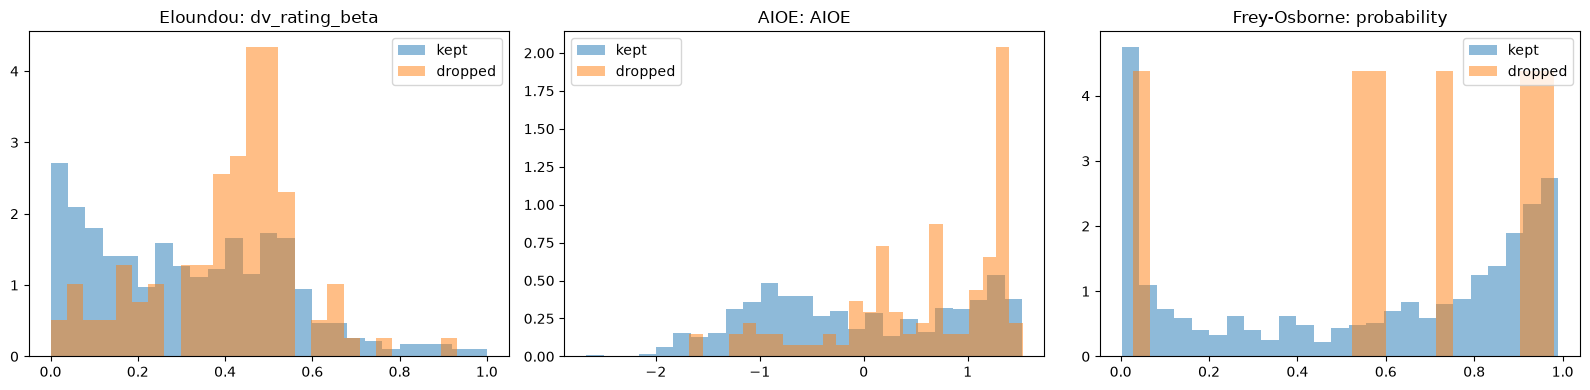

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, interim, col) in zip(axes, [("Eloundou", elo6, "dv_rating_beta"), ("AIOE", aioe_x, "AIOE"),
                                           ("Frey-Osborne", fo_x, "probability")]):
    kept = interim.soc.isin(merged.soc)
    ax.hist(interim.loc[kept, col], bins=25, alpha=0.5, density=True, label="kept")
    ax.hist(interim.loc[~kept, col], bins=25, alpha=0.5, density=True, label="dropped")
    ax.set_title(f"{name}: {col}")
    ax.legend()
fig.tight_layout()
plt.show()

In [13]:
share = pd.DataFrame({
    "SOC 2018 (all)": pd.Series([c[:2] for c in soc18]).value_counts(normalize=True),
    "merged table": merged.soc.str[:2].value_counts(normalize=True),
}).fillna(0)
share["difference (pp)"] = (share["merged table"] - share["SOC 2018 (all)"]) * 100
share.index = [f"{g} {MAJOR_GROUPS[g]}" for g in share.index]
share.sort_values("difference (pp)").round(3)

,SOC 2018 (all),merged table,difference (pp)
25 Education & Library,0.077,0.029,-4.842
29 Healthcare Practitioners,0.083,0.058,-2.532
55 Military,0.022,0.000,-2.191
15 Computer & Mathematical,0.024,0.020,-0.402
"45 Farming, Fishing & Forestry",0.016,0.013,-0.316
21 Community & Social Service,0.021,0.019,-0.200
31 Healthcare Support,0.021,0.020,-0.056
33 Protective Service,0.028,0.027,-0.026
37 Building & Grounds,0.012,0.012,0.001
23 Legal,0.009,0.010,0.087


### 7. Summary: key trends, merging, and outliers

**General trends**
- 693 occupations, 26 columns, no nulls or duplicate codes, every row scored by all three indices. The
  `.xlsx` copy matches the CSV, and every score matches its interim table exactly.
- **The two AI-exposure indices agree; Frey-Osborne does not.** Eloundou beta and AIOE have Spearman
  ≈ 0.86 (and GPT-4 vs. human beta ≈ 0.91). Frey-Osborne is weakly *negatively* related to both
  (-0.26 with Eloundou, -0.36 with AIOE). This is the expected split between measures of exposure to
  generative / cognitive AI (white-collar work) and the 2013 automation-risk measure (routine and
  manual work).
- Largest disagreements: psychologists, counselors, dietitians and postsecondary education
  administrators are highly exposed on AIOE but near-zero Frey-Osborne risk; quarry, landscaping,
  concrete and textile-machine workers are the reverse.
- By major group, Eloundou and AIOE rank groups almost the same way (legal, engineering, management and
  sales high; construction and grounds low), while Frey-Osborne ranks production, food service and
  office work highest.

**Merging**
- 105 of 693 rows carry at least one provenance flag (score averaged from several O\*NET occupations,
  copied through a split, or averaged across a merge); keep the flags in v0.
- **The three-way join is biased.** Dropped occupations are more AI-exposed than kept ones on both
  Eloundou (median beta 0.44 vs. 0.29) and AIOE (0.71 vs. -0.18); Frey-Osborne loses only 6 rows.
  Education (-4.8 pp of the table vs. all SOC 2018) and healthcare practitioners (-2.5 pp) are
  under-represented, and military is absent. Percentile ranks computed within this table will
  therefore differ from ranks within each index's full table.

**Outliers**
- No invalid values. The meaningful "outliers" are the cross-index disagreements above, which are
  substantive findings for the project question rather than errors.

### EDA techniques applied (merged table)

| Technique | What it was used for | Section |
|---|---|---|
| Null, duplicate, format and set checks | Integrity of the merged table | 1 |
| File-copy comparison (CSV vs. XLSX) | Confirm the Excel export matches | 1 |
| Reconciliation against interim tables | Every score passed through the join unchanged | 2 |
| Summary statistics + histograms | Shape of each headline index on a common row set | 3 |
| Spearman correlation matrix + heatmap | Whether the indices agree (scale-free, robust to bimodality) | 4 |
| Pairwise scatter plots | Visual form of agreement / disagreement | 4 |
| Percentile-rank gap | Occupations where the indices disagree most | 4 |
| Group-by major group, ranked medians | Whether indices order occupation families the same way | 4 |
| Flag counting | Provenance: copied or averaged scores | 5 |
| Kept vs. dropped comparison + histograms | Selection bias from the three-way join | 6 |
| Composition comparison vs. SOC 2018 | Which occupation families are under-represented | 6 |

## Part 2 — Coverage report (`coverage_report_v0.csv`)

### 1. Load + reconcile

In [14]:
cov = pd.read_csv(data_file("processed/coverage_report_v0.csv"))
print("rows:", len(cov), "| columns:", list(cov.columns), "| duplicate codes:", cov.soc.duplicated().sum())
print(cov.reason.value_counts().to_string())

universe = set(elo6.soc) | set(aioe_x.soc) | set(fo_x.soc)
print(f"\nmerged {len(merged)} + dropped {len(cov)} = {len(merged) + len(cov)}"
      f" | codes in any interim table: {len(universe)} | overlap: {len(set(merged.soc) & set(cov.soc))}")
print("SOC 2018 codes in no index at all (not in the report):", len(soc18 - universe))

rows: 115 | columns: ['soc', 'has_eloundou', 'has_aioe', 'has_frey_osborne', 'reason'] | duplicate codes: 0
reason
missing_from_frey_osborne                 97
missing_from_aioe_and_frey_osborne         8
missing_from_eloundou                      6
missing_from_eloundou_and_frey_osborne     4

merged 693 + dropped 115 = 808 | codes in any interim table: 808 | overlap: 0
SOC 2018 codes in no index at all (not in the report): 59


### 2. Who is dropped

In [15]:
cov["major_group"] = cov.soc.str[:2].map(lambda g: f"{g} {MAJOR_GROUPS[g]}")
pd.crosstab(cov.major_group, cov.reason, margins=True).sort_values("All", ascending=False)

reason,missing_from_aioe_and_frey_osborne,missing_from_eloundou,missing_from_eloundou_and_frey_osborne,missing_from_frey_osborne,All
major_group,,,,,
All,8,6,4,97,115
25 Education & Library,0,1,1,42,44
29 Healthcare Practitioners,1,0,1,29,31
15 Computer & Mathematical,1,0,0,6,7
33 Protective Service,1,0,0,3,4
31 Healthcare Support,0,0,0,4,4
13 Business & Financial,0,0,0,3,3
11 Management,1,0,1,1,3
47 Construction & Extraction,0,1,0,2,3


In [16]:
titles18 = cw.drop_duplicates("soc18").set_index("soc18").title18
cov["title"] = cov.soc.map(titles18)
cov.loc[cov.reason == "missing_from_frey_osborne", ["soc", "title"]].head(20)

,soc,title
2,11-9171,Funeral Home Managers
3,13-1071,Human Resources Specialists
4,13-1075,Labor Relations Specialists
5,13-1131,Fundraisers
6,15-1212,Information Security Analysts
7,15-1231,Computer Network Support Specialists
8,15-1232,Computer User Support Specialists
9,15-1241,Computer Network Architects
10,15-1254,Web Developers
11,15-1255,Web and Digital Interface Designers (##)


### 3. How many drops are recoverable?
Frey-Osborne's broad codes (see `eda_interim.ipynb`, Part 3) could be expanded to their detailed children.

In [17]:
fo_log = pd.read_csv(data_file("interim/frey_osborne_coverage_log.csv"), dtype={"soc2010": str})
broad = fo_log[fo_log.soc2010.str.endswith("0")].soc2010
recoverable = set()
for b in broad:
    recoverable |= set(cw.loc[cw.soc10.str.startswith(b.rstrip("0")), "soc18"])
fo_drops = cov[cov.reason == "missing_from_frey_osborne"]
n_rec = fo_drops.soc.isin(recoverable).sum()
print(f"'missing_from_frey_osborne' drops: {len(fo_drops)} | recoverable from broad FO codes: {n_rec}")
print(f"merged table would grow from {len(merged)} to {len(merged) + n_rec} rows")

'missing_from_frey_osborne' drops: 97 | recoverable from broad FO codes: 57
merged table would grow from 693 to 750 rows


### 4. Summary: key trends, merging, and outliers

**General trends**
- 115 dropped occupations, no duplicates. Merged (693) + dropped (115) = 808 = every code that appears
  in at least one index, with no overlap, so the report is complete. 59 SOC 2018 codes appear in no
  index at all (mostly military) and are not in the report.
- Frey-Osborne causes almost all drops: `missing_from_frey_osborne` is 97 of 115, and 12 more involve
  Frey-Osborne together with another index.

**Merging**
- Drops are concentrated in education (44, mostly postsecondary teachers) and healthcare
  practitioners (31), plus newer computer occupations (information security, web developers).
- **57 of the 97 Frey-Osborne drops are recoverable** by expanding its broad codes (Postsecondary
  Teachers, Physicians and Surgeons, ...) to their detailed children; the merged table would grow from
  693 to 750 rows and much of the education/healthcare bias would go away. Most of the rest come from
  SOC 2000 codes that need a hand mapping (e.g. Registered Nurses).
- Recommendation: fix this in Task 3b before finalising v0, keep the coverage report as the record of
  what is still missing (don't delete data), and add a provenance flag for recovered rows.

**Outliers**
- None in the usual sense; the report is a list of codes. The pattern of *which* codes are missing is
  the finding.

### EDA techniques applied (coverage report)

| Technique | What it was used for | Section |
|---|---|---|
| Frequency counts of drop reasons | Which index causes the drops | 1 |
| Set reconciliation (merged + dropped = union of indices) | Completeness of the report | 1 |
| Cross-tabulation (major group × reason) | Where the drops are concentrated | 2 |
| Title lookup from the crosswalk | Readable list of dropped occupations | 2 |
| What-if recovery via broad-code expansion | How many drops a mapping fix would restore | 3 |

## Result and retained limitations

- The merged table and coverage report are complete and consistent: 693 + 115 = 808 occupations, every
  score matches its interim source, and the Excel copy matches the CSV.
- **First answer to the project question:** the two AI-exposure indices agree (Eloundou beta vs. AIOE,
  Spearman ≈ 0.86). Frey-Osborne's automation risk is weakly *negatively* related to both.
- **The merged table is not a neutral sample.** Occupations dropped by the join are more AI-exposed on
  both Eloundou and AIOE, and education and healthcare are under-represented. 57 of the 97
  Frey-Osborne-caused drops could be recovered by expanding broad codes in Task 3.

This notebook does not fix the join or compute ranks. **Next:**
[`task7_percentile_ranks.ipynb`](task7_percentile_ranks.ipynb) puts the indices on a common 0-100 scale.